# hw 6

In [67]:
import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt
from matplotlib import rc
import matplotlib as mpl
import ccdproc as ccdp
from astropy.nddata import CCDData
from astropy import units as u
import glob
import pandas as pd
from photutils import aperture
from astropy.modeling import models, fitting

In [68]:
phot_tut_dir = '/Users/vasqum2/class/astr_8060_s26/work/mvasq/convenience_functions.py'
import sys
sys.path.insert(0, phot_tut_dir)
from convenience_functions import show_image

plt.style.use('guide.mplstyle')

rc('font', size=20)
rc('axes', grid=True)

In [69]:
data_dir = '/Users/vasqum2/class/astr_8060_s26/work/mvasq/Imaging/'
data_red = '/Users/vasqum2/class/astr_8060_s26/work/mvasq/reduced/'

img_paths = sorted(glob.glob(data_dir + 'a[0-2]??.fits'))
linearity_test_paths = img_paths[73:80]
print(linearity_test_paths)

['/Users/vasqum2/class/astr_8060_s26/work/mvasq/Imaging/a074.fits', '/Users/vasqum2/class/astr_8060_s26/work/mvasq/Imaging/a075.fits', '/Users/vasqum2/class/astr_8060_s26/work/mvasq/Imaging/a076.fits', '/Users/vasqum2/class/astr_8060_s26/work/mvasq/Imaging/a077.fits', '/Users/vasqum2/class/astr_8060_s26/work/mvasq/Imaging/a078.fits', '/Users/vasqum2/class/astr_8060_s26/work/mvasq/Imaging/a079.fits', '/Users/vasqum2/class/astr_8060_s26/work/mvasq/Imaging/a080.fits']


/var/folders/ym/gbj1z46s0wg5zdmkkq0xpptr0000gs/T/ipykernel_18443/3231267026.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  med = float(here['aperture_sum'])/int(np.pi*(10**2))
/var/folders/ym/gbj1z46s0wg5zdmkkq0xpptr0000gs/T/ipykernel_18443/3231267026.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  med = float(here['aperture_sum'])/int(np.pi*(10**2))
/var/folders/ym/gbj1z46s0wg5zdmkkq0xpptr0000gs/T/ipykernel_18443/3231267026.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (De

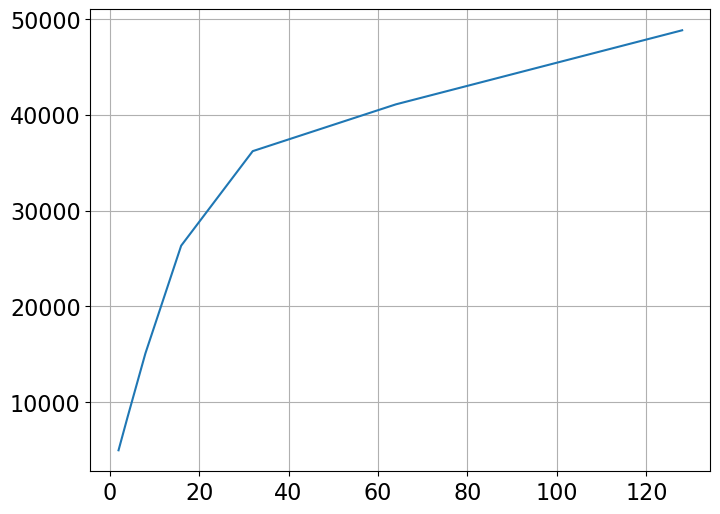

In [70]:
exp_times = [2, 4, 8, 16, 32, 64, 128]
meds = []

ap = aperture.CircularAperture((670, 1717),10)
for path in linearity_test_paths:
    data = fits.open(path)
    img = data[0].data

    here = aperture.aperture_photometry(img, ap)
    med = float(here['aperture_sum'])/int(np.pi*(10**2))
    meds.append(med)

plt.figure(figsize=(8,6))
plt.plot(exp_times, meds)
# plt.semilogy(base=2)

i tested to see what position and aperture the star i chose is at, and then found the median value of the pixels that it covered. this star was chosen as it was one of the brightest stars within the FOV, and in the images with longer exposure times, it showed column bleeding, indicating that it was saturating, and thus would be a good showcase for the linearity test.

it looks a little linear, but there is not a clear linear regime. more data is needed.

## 2

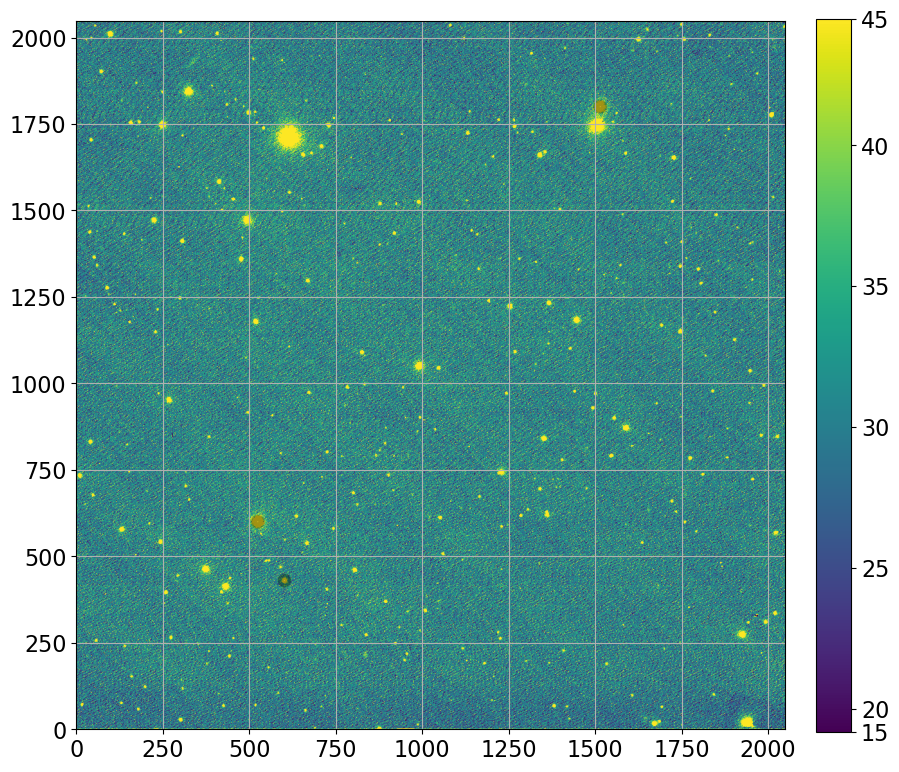

In [140]:
pg_1_path = '/Users/vasqum2/class/astr_8060_s26/work/mvasq/Imaging/a081otz.fits'
pg_1_df = fits.open(pg_1_path)
pg_1_img = pg_1_df[0].data

positions = [(602, 430), (1515, 1800), (525, 600)]
r_in = np.arange(1,20,1)
snr = np.zeros((len(r_in), 3))
i = 0
ax = show_image(pg_2_img)
for r in r_in:
    apert = aperture.CircularAperture(positions,r)
    annul = aperture.CircularAnnulus(positions, r_in = 40, r_out = 50)

    apert_phot = aperture.aperture_photometry(pg_2_img, apert)['aperture_sum']
    apert_tot = apert_phot
    apert_med = apert_tot / apert.area
    annul_tot = aperture.aperture_photometry(pg_2_img, annul)['aperture_sum']
    annul_med = annul_tot / annul.area

    apert.plot(ax=ax, alpha=0.1)
    snr_top = apert_tot-(annul_med*apert.area)
    snr_bot = np.sqrt(snr_top + apert.area*((apert_tot/annul_tot)**2 + 14**2))
    snr_now = snr_top/snr_bot
    # print(apert_tot)
    # annul_med = float(annul_tot['aperture_sum'])/annul_area
    snr[i] = snr_now
    i+=1

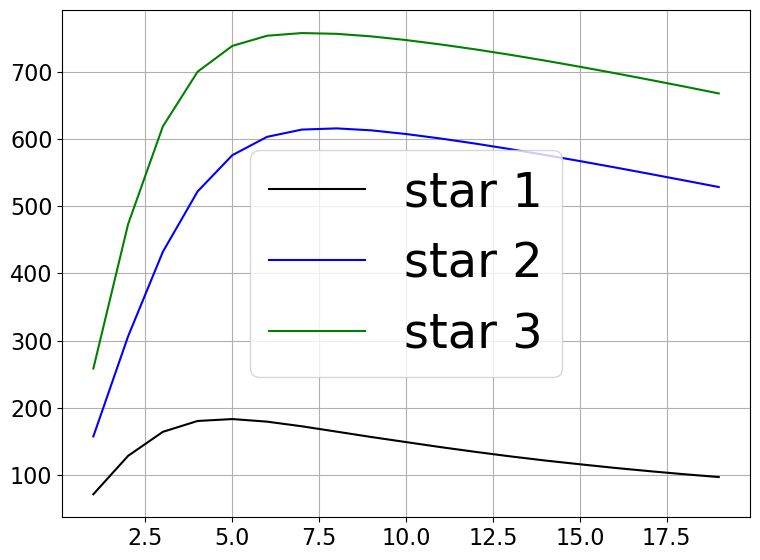

In [141]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(r_in, snr[:,0], 'k', label='star 1')
ax.plot(r_in, snr[:,1], 'b', label='star 2')
ax.plot(r_in, snr[:,2], 'g', label='star 3')
plt.legend()
plt.tight_layout()

faintest -> medium bright -> brightest from 1-2-3
they all showcase the same pattern showed in Howell, from this its clear that the best aperture range in 5-7, i will choose the median and go 6 :))

## 3

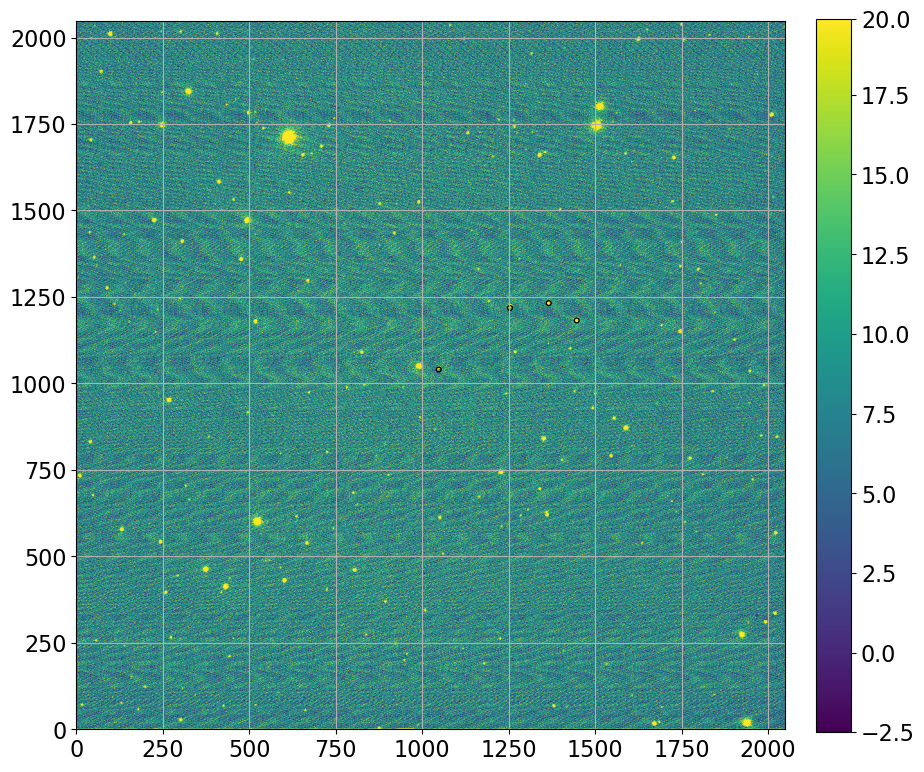

In [73]:
standard_p = [(1048, 1040), (1254, 1218), (1366, 1232), (1447, 1182)]
standards_ap = aperture.CircularAperture(standard_p,7)

# ax.yaxis.set_inverted(True)
ax = show_image(pg_1_img)
standards_ap.plot(ax=ax)

found standard stars A, B, C, and D (in that order in the positions list)
## 4
$$ m = -2.5*log(S) = -2.5*log(T-AB)$$
S = source,
B = background,
A = area,
T = total signal

In [74]:
pg_2_path = '/Users/vasqum2/class/astr_8060_s26/work/mvasq/reduced/a082otz.fits'
pg_2_df = fits.open(pg_2_path)
pg_2_img = pg_2_df[0].data

standards_an = aperture.CircularAnnulus(standard_p, 40, 50)
T = aperture.aperture_photometry(pg_2_img, standards_ap)['aperture_sum']

back_tot = aperture.aperture_photometry(pg_2_img, standards_an)
B = back_tot['aperture_sum']/ standards_an.area
m = -2.5*np.log(T - standards_ap.area*B)
print(m)

    aperture_sum   
-------------------
 -23.31752039438989
  -26.7180883939243
-25.820943080766924
 -28.48365990044321


im unsure if these are accurate or not, as instrumental magnitudes have no physical meaning. something feels wrong about this though,,,,,,
## 5

In [75]:
def inst_mag(path, positions):
    df = fits.open(path)
    data = df[0].data
    standards_ap = aperture.CircularAperture(positions,6)
    standards_an = aperture.CircularAnnulus(positions, 20, 40)

    T = aperture.aperture_photometry(data,standards_ap)['aperture_sum']
    back_tot = aperture.aperture_photometry(data, standards_an)
    B = back_tot['aperture_sum']/ standards_an.area
    inside = T - standards_ap.area*B
    # print(T, standards_ap.area, B)
    m = -2.5*np.log(inside)

    return m

In [143]:
pgs = sorted(glob.glob(data_red + 'a[0-2]??otz.fits'))
inst_mags = np.zeros((6, 4))
i = 0
positions = {'130' : [(990, 1037), (1197, 1216), (1309, 1225), (1389, 1176)],
             '131' : [(989, 1037), (1196, 1215), (1308, 1225), (1388, 1176)],
             '202' : [(981, 1031), (1188, 1209), (1300, 1218), (1377, 1169)], 
             '203' : [(982, 1030), (1189, 1209), (1301, 1218), (1381, 1169)],
             '237' : [(893, 1032), (1100, 1210), (1212, 1220), (1292, 1171)],
             '238' : [(893, 1033), (1100, 1211), (1212, 1220), (1292, 1171)]}

for path in pgs[1:]:
    file = path[55:58]
    if file in positions:
        m = inst_mag(path, positions[file])
        inst_mags[i] = m
        i += 1
inst_mags

array([[-23.24455503, -26.64169682, -25.70893278, -28.34335034],
       [-23.27959209, -26.72328684, -25.7532867 , -28.35629211],
       [-23.0833558 , -26.46505691, -25.58016535, -28.04787592],
       [-23.1747117 , -26.46122557, -25.53661252, -28.14813065],
       [-22.33656655, -25.83376762, -24.87034656, -27.40567559],
       [-22.26993846, -25.76667984, -24.85781624, -27.38617528]])

[Parameter('slope', value=-1.0882517811223296), Parameter('slope', value=-0.9717460545784695), Parameter('slope', value=-0.9681297936701528), Parameter('slope', value=-1.0466225964675901)]


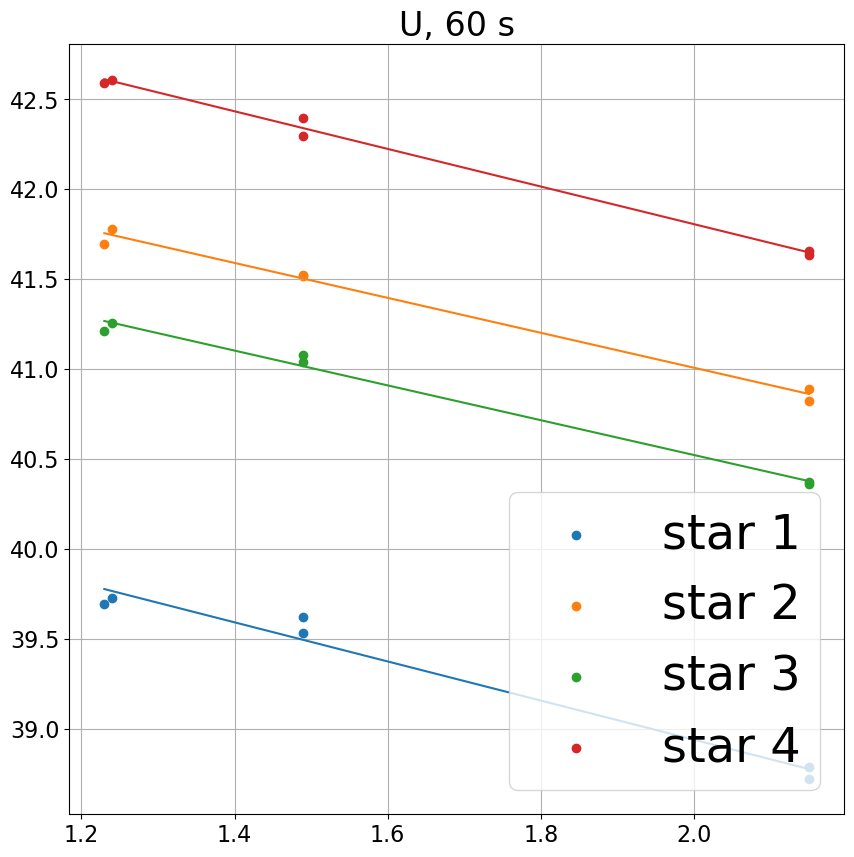

In [146]:
V = np.array([15.256, 12.969, 13.229, 13.691])
B_V = np.array([0.873, 1.081, 1.134, 0.535])
U_B = np.array([0.32, 1.007, 1.138, 0.025])
V_R = np.array([0.505, 0.590, 0.618, 0.324])

airmasses = [1.23, 1.24, 1.49, 1.49, 2.15, 2.15]
i = 0

fit = fitting.LinearLSQFitter()
line_init = models.Linear1D()
slopes = []
while i < 4:
    u = U_B + B_V + V
    star = i + 1
    # print(airmasses, inst_mags)
    fitted_line = fit(line_init, airmasses, u[i] - inst_mags[:][:,i])
    slopes.append(fitted_line.slope)
    plt.scatter(airmasses, u[i] - inst_mags[:][:,i], label = 'star ' + str(star))
    plt.plot(airmasses, fitted_line(airmasses))
    i += 1
plt.title('U, 60 s')
plt.legend()
print(slopes)

from this, its clear the extinction coefficient is ~ -1

# do this for other bands

In [147]:
# V band
B_nums = ['083', '084', '132', '133', '204', '205', '239', '240']
V_nums = ['085', '086', '134', '135', '206', '207', '241', '242']
R_nums = ['087', '088', '136', '137', '208', '209', '243', '244']

nums = {'B' : B_nums, 'V' : V_nums, 'R' : R_nums}
pos = {'083' : [(1046.3694, 1044.2474), (1253.1379, 1222.0416), (1365.9272, 1232.0345), (1445.7996, 1183.1615)],
       '084' : [(1045.6691, 1043.4659), (1252.9119, 1221.8906), (1364.6779, 1231.6922), (1444.6431, 1183.0479)],
       '085' : [(1045.6586, 1045.6586), (1252.3936, 1222.1635), (1365.2397, 1232.3925), (1445.5474, 1182.9634)],
       '086' : [(1044.9921, 1044.0702), (1251.8046, 1221.9312), (1364.2093, 1232.1586), (1443.9924, 1182.6467)],
       '087' : [(1045.6357, 1044.5431), (1252.6085, 1223.3024), (1364.9872, 1232.7583), (1444.8888, 1183.8577)],
       '088' : [(1044.085, 1043.9989), (1250.6203, 1222.098), (1362.8519, 1231.7591), (1443.1973, 1182.8336)],
       '132' : [(989.57116, 1038.0712), (1195.8088, 1216.1084), (1308.1404, 1225.8603), (1388.6146, 1177.0078)],
       '133' : [(988.54387, 1037.9606), (1195.6568, 1216.2055), (1307.0628, 1223.0023), (1384.4356, 1176.8735)],
       '134' : [(988.51864, 1038.39), (1195.5757, 1216.7355), (1308.0235, 1225.8988), (1388.428, 1177.3282)],
       '135' : [(988.76225, 1038.2309), (1196.2409, 1216.5298), (1308.4151, 1225.5777), (1388.3375, 1176.9791)],
       '136' : [(988.12988, 1039.4103), (1195.0097, 1217.2437), (1307.8138, 1226.7788), (1387.5058, 1178.0265)],
       '137' : [(988.2896, 1039.1978), (1195.5851, 1217.4991), (1308.1426, 1226.6857), (1387.863, 1178.0462)],
       '204' : [(981.57124, 1031.1786), (1188.9783, 1209.5298), (1301.164, 1218.9421), (1381.1626, 1381.1626)],
       '205' : [(981.13923, 1031.7819), (1188.0435, 1209.2761), (1300.0285, 1218.999), (1380.2295, 1380.2295)],
       '206' : [(981.46972, 1031.7793), (1188.4378, 1209.6549), (1300.7123, 1219.5686), (1219.5686, 1170.5021)],
       '207' : [(982.51003, 1031.4177), (1189.7546, 1209.7821), (1301.8797, 1218.9787), (1381.6236, 1170.0054)],
       '208' : [(981.21335, 1032.4208), (1188.6892, 1211.0386), (1300.9226, 1220.3657), (1380.6269, 1171.026)],
       '209' : [(982.03748, 1032.4087), (1188.9046, 1210.4427), (1301.0009, 1220.02), (1380.9452, 1171.0853)],
       '239' : [(894.15144, 1033.457), (1101.0781, 1211.9868), (1213.7941, 1221.3078), (1293.6861, 1172.1167)],
       '240' : [(894.73931, 1034.627), (1101.0618, 1212.0617), (1213.2856, 1221.8114), (1293.5161, 1172.3499)],
       '241' : [(895.03581, 1035.002), (1102.5157, 1212.725), (1213.8662, 1222.3156), (1294.7219, 1173.4944)],
       '242' : [(894.87905, 1034.5085), (1102.0887, 1215.8174), (1214.1687, 1221.4277), (1293.8617, 1173.0411)],
       '243' : [(893.98795, 1035.9523), (1100.9404, 1213.6459), (1212.705, 1222.3933), (1293.1611, 1174.1573)],
       '244' : [(896.84173, 1034.5445), (1103.4348, 1212.5784), (1215.9947, 1222.5753), (1295.6868, 1173.6178)]}

airmass = {'083' : [1.18], '084' : [1.18], '085' : [1.18], '086' : [1.18], '087' : [1.18], '088' : [1.18],
           '132' : [1.23], '133' : [1.24], '134' : [1.24], '135' : [1.24], '136' : [1.24], '137' : [1.24],
           '204' : [1.49], '205' : [1.49], '206' : [1.51], '207' : [1.51], '208' : [1.52], '209' : [1.52], 
           '239' : [2.19], '240' : [2.19], '241' : [2.21], '242' : [2.21], '243' : [2.23], '244' : [2.23]}


/var/folders/ym/gbj1z46s0wg5zdmkkq0xpptr0000gs/T/ipykernel_18443/2972286031.py:12: RuntimeWarning: invalid value encountered in log
  m = -2.5*np.log(inside)
/var/folders/ym/gbj1z46s0wg5zdmkkq0xpptr0000gs/T/ipykernel_18443/3103753640.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/ym/gbj1z46s0wg5zdmkkq0xpptr0000gs/T/ipykernel_18443/3103753640.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Parameter('slope', value=-0.5970880656530493)
Parameter('slope', value=-0.5820617804692273)
Parameter('slope', value=-0.5986881607007389)
Parameter('slope', value=nan)
Parameter('slope', value=-0.8751964109731902)
Parameter('slope', value=-1.3386038660834119)
Parameter('slope', value=-0.8631305129984062)
Parameter('slope', value=-0.46036185001334334)
Parameter('slope', value=-0.44629801834287036)
Parameter('slope', value=-0.398986668354811)
Parameter('slope', value=-0.40300380305923017)
Parameter('slope', value=-0.44924592200932645)


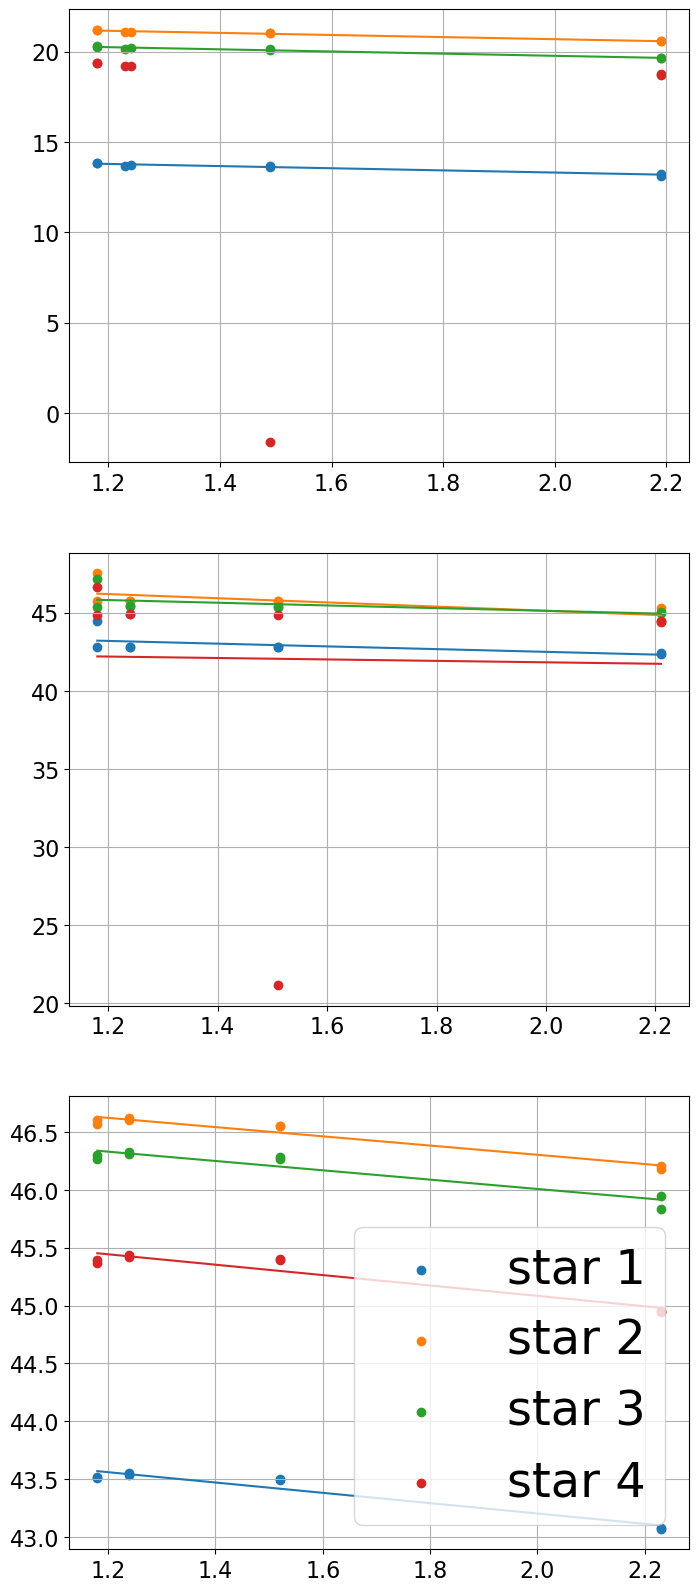

In [148]:
inst_mags = {}
path_beg = pgs[0][:55]
path_end = pgs[0][58:]
fig, ax = plt.subplots(3, 1, figsize=(8,20))
ext_coeff = {}
a = 0
mags = {}
for filt in nums:
    if filt == 'B':
        true_mags = B_V - V
    elif filt == 'V':
        true_mags = V
    elif filt == 'R':
        true_mags = V - V_R
    temp_mags = np.zeros((len(nums[filt]), 4))
    temp_airmass = np.zeros((len(nums[filt])))
    i = 0

    for num in nums[filt]:
        path = path_beg + num + path_end
        m = inst_mag(path, pos[num])
        temp_mags[i] = m
        temp_airmass[i] = airmass[num][0]
        mags[num] = m
        i += 1
    # print(f'\n\ntempmags: {temp_mags}')
    s = 0
    slope = 0
    while s < 4:
        star = s + 1
        dif = true_mags[s] - temp_mags[:][:,s]
        fitted_line = fit(line_init, temp_airmass, dif)
        print(fitted_line.slope)
        ax[a].scatter(temp_airmass, dif, label = 'star ' + str(star))
        ax[a].plot(temp_airmass, fitted_line(temp_airmass))
        s += 1
    # ext_coeff[filt] = slope/4
    # print(slope)
    plt.legend()
    a += 1

In [150]:
b_k = -np.mean([0.5970880656530473, 0.5970880656530473, 0.5970880656530473])
v_k = -np.mean([0.8751964109731921, 1.3386038660834154, 0.863130512998406, 0.4603618500133462])
r_k = -np.mean([0.4462980183428679, 0.3989866683548202, 0.40300380305922284, 0.4492459220093292])
print(b_k, v_k, r_k)

-0.5970880656530473 -0.8843231600170899 -0.4243836029415601


this is the extinction coefficients for B, V, and R. something seems to be wrong like i was saying, as there are a few points that do not fit the expected behavior at all (having a much lower magnitude than the others). i dont think anything is wrong here?

## 6

In [157]:
for filt in nums:
    mean_mag[filt] = 0
    if filt == 'B':
        k = b_k
    elif filt == 'V':
        k = v_k
    elif filt =='R':
        k = r_k

    for num in nums[filt]:
        mags[num] -= k*airmass[num][0]

In [152]:
nums['V'][0]

'085'

In [153]:
v = []
v_r = []
b_v = []
i = 0

while i < len(nums['V']):
    b_num = nums['B'][i]
    v_num = nums['V'][i]
    r_num = nums['R'][i]
    
    v_r_now = mags[v_num] - mags[r_num]
    b_v_now = mags[b_num] - mags[v_num]
    v_r.append(v_r_now)
    b_v.append(b_v_now)
    v.append(mags[v_num])
    print(f'num : {v_num},\n v: {mags[v_num]}\n v_r : {v_r_now},\n\n b_v : {b_v_now}')
    i += 1

num : 085,
 v:     aperture_sum   
-------------------
 -28.16994895377776
 -33.51051994229456
 -32.88018845254038
-31.913397539284784
 v_r :     aperture_sum    
--------------------
 0.08836255592822084
  0.1761025576146551
  0.2768864602896741
-0.41228746194183685,

 b_v :    aperture_sum   
------------------
  0.67124665571097
1.1201143735400336
1.2069125037005435
0.0829096710909134
num : 086,
 v:     aperture_sum   
-------------------
-26.476709946953395
-31.717298854427522
 -31.09497672426981
 -30.15105220666535
 v_r :    aperture_sum   
------------------
1.7879584066155303
2.0047637502129767
   2.0923953268119
1.3767609657092805,

 b_v :     aperture_sum   
-------------------
 -1.050821813940967
-0.6601625945701848
-0.5915957712954132
-1.6834379531153054
num : 134,
 v:     aperture_sum   
-------------------
-26.475803609517097
-31.705548425978602
 -31.12458874054862
 -30.11521157395878
 v_r :    aperture_sum   
------------------
1.7969838576775317
2.0105154517287893
 2.067

In [154]:
b_v_2d = np.array(b_v)
b_v_1d = b_v_2d.ravel()
v_r_2d = np.array(v_r)
v_r_1d = v_r_2d.ravel()
v_2d = np.array(v)
v_1d = v_2d.ravel()

In [155]:
b_v_fit = fit(line_init, b_v_1d, v_1d)
v_r_fit = fit(line_init, v_r_1d, v_1d)

fig, ax = plt.subplots(figsize=(8,6))
plt.plot(b_v_1d, b_v_fit(b_v_1d))
ax.scatter(b_v, v)
ax.yaxis.set_inverted(True)

LinAlgError: SVD did not converge in Linear Least Squares

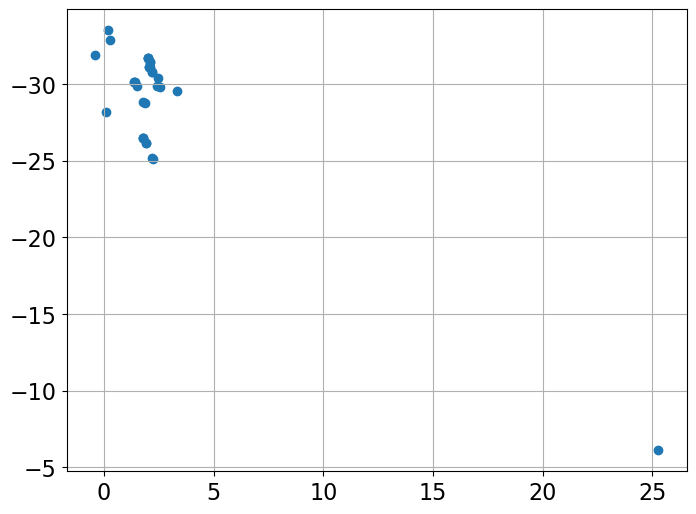

In [156]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(v_r, v)
ax.yaxis.set_inverted(True)

something i did earlier is preventing these from working, the object with -10 as its magnitude is preventing the model from even providing a line. idk :((

i know its star D, there's trails of something clearly not being right in the airmass vs instrumental magnitude plots i made before, and in there the star also prevented another model from converging (specifically in the B band). im unsure why? its treated the same as the others and doesnt seem particularly different in those images.